# Supplementary material II

**The circularity paradox in secondhand products: high value retained leads to low environmental benefits and high rebound**

Rafael Laurenti

# Script pipeline

*Circularity paradox* workflow:

1. Ingest & clean raw marketplace data 
2. Category & market summaries 
3. Representative products, prices, and economic benefits 
4. Household CF factors for Sweden 
5. Potential environmental benefits 
6. Economic and environmental benefits 
7. Re‑spending effects 
8. Circular rebound effect computation

**Folders created automatically:** `raw/ processed/ derived/ factors/ results/`  
**Convention:** internal Parquet; CSV/Excel not internally used exported to `derived/`; Table results amd plots exported to `results/`

**Initial files needed:** 
`raw/scraped_data.xlsx` # Raw data scraped from the marketplace.
    
`factors/df_32cat_CFexio_RL.xlsx` # 32 marketplace product categories matched with the 200 EXIOBASE product categories + impact factor (GHG emissions per M EUR).
In the cases where the matches were one-to-many, an average value of the environmental stressors is calculated.    

`factors/Exio_COICOP12.xlsx` # Concordance file matching the 200 EXIOBASE product categories with 12 COICOP categories.

`factors/EXIOBASE341f_CC500f.csv` # Characterization file used to convert envitonmental stressors into impact factors [GHG emissions (GWP100)|kg CO2 eq.|Problem oriented approach: baseline (CML, 2001)|GWP100 (IPCC, 2007)]

`factors/retail_prices_representative_products.yaml` # Retail price of the 32 representative products.

## 00 Config & utilities

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import os
import shutil

# --- Run identifier ---
RUN_ID = "2025-11-03"

# --- Base paths ---
BASE = Path(".")

# Shared across runs
RAW = BASE / "raw"
FAC = BASE / "factors"

# Versioned per run
PROC = BASE / f"processed_{RUN_ID}"
DER  = BASE / f"derived_{RUN_ID}"
RES  = BASE / f"results_{RUN_ID}"

# --- Create folders ---
for p in [RAW, FAC, PROC, DER, RES]:
    p.mkdir(parents=True, exist_ok=True)

# (Optional) point convenience aliases to the current run (processed_latest → processed_YYYY-MM-DD, etc.)
def _set_latest_alias(target: Path, alias: Path):
    """Create/refresh a 'latest' alias pointing to target. Tries symlink, falls back to removing+copying."""
    try:
        if alias.exists() or alias.is_symlink():
            if alias.is_symlink() or alias.is_file():
                alias.unlink()
            else:
                shutil.rmtree(alias)
        alias.symlink_to(target, target_is_directory=True)
    except Exception:
        # Symlinks may require admin rights on Windows; fall back to a lightweight dir with a marker file.
        alias.mkdir(parents=True, exist_ok=True)
        (alias / "_LATEST_POINTS_TO.txt").write_text(str(target.resolve()), encoding="utf-8")

# Create/update aliases (only for versioned dirs)
_set_latest_alias(PROC, BASE / "processed_latest")
_set_latest_alias(DER,  BASE / "derived_latest")
_set_latest_alias(RES,  BASE / "results_latest")

# --- Safe writer ---
def write_df(df: pd.DataFrame, path: Path, enforce: bool = False):
    """Safe writer: refuses to overwrite unless enforce=True."""
    if path.exists() and not enforce:
        raise FileExistsError(f"{path} exists (set enforce=True to overwrite).")
    if path.suffix == ".parquet":
        df.to_parquet(path, index=False)
    elif path.suffix == ".csv":
        df.to_csv(path, index=False)
    elif path.suffix in (".feather", ".arrow"):
        df.to_feather(path)
    else:
        raise ValueError("Use .parquet or .csv/.feather")


## 01 Ingest & Clean

In [23]:
import pandas as pd
import numpy as np
import re

def clean(df_raw: pd.DataFrame, show_summary: bool = True) -> pd.DataFrame:
    """
    Clean scraped data:
    - Parse Price to float
    - Drop NaN Category/Price
    - Remove 3%–97% outliers per category
    - Translate Category names to English
    - Optionally print summary of removed rows per category
    """
    df = df_raw.copy()

    # --- Parse Price ---------------------------------------------------------
    price_str = (
        df['Price']
        .astype(str)
        .str.replace(r"[^\d,.\-]", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    df['Price'] = pd.to_numeric(price_str, errors='coerce')

    # --- Drop rows missing essentials ---------------------------------------
    df_dirty = df.dropna(subset=['Category', 'Price']).copy()

    # --- Outlier filtering (vectorized) -------------------------------------
    q_low = df_dirty.groupby('Category')['Price'].transform(lambda s: s.quantile(0.03))
    q_hi  = df_dirty.groupby('Category')['Price'].transform(lambda s: s.quantile(0.97))
    df_cleaned = df_dirty[(df_dirty['Price'] > q_low) & (df_dirty['Price'] < q_hi)].copy()

    # --- Per-category summary -----------------------------------------------
    summary = (
        df_dirty['Category']
        .value_counts()
        .rename('Before')
        .to_frame()
        .join(df_cleaned['Category'].value_counts().rename('After'))
        .fillna(0)
        .astype(int)
    )
    summary['Removed'] = summary['Before'] - summary['After']
    summary['% Removed'] = (summary['Removed'] / summary['Before'] * 100).round(1)

    if show_summary:
        print("=== Outlier Removal Summary ===")
        print(summary)
        print("\nTotal rows before:", len(df_dirty))
        print("Total rows after:", len(df_cleaned))
        print("Overall removed:", len(df_dirty) - len(df_cleaned))

    # --- Category translation -----------------------------------------------
    dic_cat = {
        'Motorcyklar': 'Motorcycles',
        'Bildelar & biltillbehör': 'Car parts & car accessories',
        'Möbler & heminredning': 'Furniture & home decor',
        'Sport- & fritidsutrustning': 'Sports & leisure equipment',
        "Barnkläder & skor": "Children's clothing & shoes",
        'MC-delar & tillbehör': 'Motorcycle parts & accessories',
        'Ljud & bild': 'Audio & video',
        'Bilar': 'Cars',
        'Datorer & TV-spel': 'Computers & video games',
        'Bygg & trädgård': 'Construction & garden',
        'Övrigt': 'Other',
        'Husgeråd & vitvaror': 'Housewares & appliances',
        'Kläder & skor': 'Clothes & shoes',
        'Barnartiklar & leksaker': "Children's articles & toys",
        'Husvagnar & husbilar': 'Caravans & campers',
        'Skogs- & lantbruksmaskiner': 'Forestry & agricultural machinery',
        'Musikutrustning': 'Music equipment',
        'Inventarier & maskiner': 'Fixtures & machines',
        'Telefoner & tillbehör': 'Phones & accessories',
        'Böcker & studentlitteratur': 'Books & student literature',
        'Verktyg': 'Tools',
        'Hästar & ridsport': 'Horses & equestrian',
        'Båtdelar & tillbehör': 'Boat parts & accessories',
        'Mopeder & A-traktor': 'Mopeds & doodlebug tractors',
        'Cyklar': 'Bicycles',
        'Lastbil, truck & entreprenad': 'Trucks & construction',
        'Båtar': 'Boats',
        'Snöskotrar': 'Snowmobiles',
        'Accessoarer & klockor': 'Accessories & watches',
        'Hobby & samlarprylar': 'Hobby & collectibles',
        'Jakt & fiske': 'Hunting & fishing',
        'Snöskoterdelar & tillbehör': 'Snowmobile parts & accessories',
    }
    df_cleaned['Category'] = df_cleaned['Category'].replace(dic_cat)

    return df_cleaned


In [24]:
# run
df_raw = pd.read_excel(RAW / 'scraped_data.xlsx')
df_clean = clean(df_raw)

# Write Parquet file 
df_clean.to_parquet(PROC / 'df_cleaned_en.parquet', index=False)

# Write CSV file
df_clean.to_csv(DER / 'df_cleaned_en.csv', index=False)

# Descriptives
df_clean.groupby('Category')['Price'].describe().to_csv(DER / 'df_cleaned_en_described.csv')


=== Outlier Removal Summary ===
                              Before  After  Removed  % Removed
Category                                                       
Möbler & heminredning          57947  53031     4916        8.5
Bildelar & biltillbehör        26497  24627     1870        7.1
Bilar                          24254  22679     1575        6.5
Kläder & skor                  17085  15788     1297        7.6
Barnartiklar & leksaker        16145  15060     1085        6.7
Bygg & trädgård                16122  15081     1041        6.5
Barnkläder & skor               9041   8386      655        7.2
Sport- & fritidsutrustning      8987   8431      556        6.2
Ljud & bild                     7715   7251      464        6.0
Husgeråd & vitvaror             6917   6488      429        6.2
Datorer & TV-spel               6387   5971      416        6.5
Cyklar                          5825   5362      463        7.9
Motorcyklar                     4866   4534      332        6.8
Musikutr

## 02 Category & Market Summaries

In [25]:
import pandas as pd
from typing import Tuple

def _ensure_price_numeric(df: pd.DataFrame) -> pd.DataFrame:
    if not pd.api.types.is_numeric_dtype(df['Price']):
        df = df.copy()
        df['Price'] = (
            df['Price']
            .astype(str)
            .str.replace('kr', '', regex=False)
            .str.replace(' ', '', regex=False)
            .str.replace(',', '.', regex=False)
            .astype(float)
        )
    return df

def build_category_overview(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return per-category overview: counts, total value, average price, spread stats,
    plus ranks and share columns. No I/O, no prints.
    Requires columns: Category, Price.
    """
    req = {'Category', 'Price'}
    missing = req - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    df = _ensure_price_numeric(df)

    g = df.groupby('Category', observed=True)['Price']
    stats = g.agg(
        **{
            '# of products': 'size',
            'Average product price [SEK]': 'mean',
            'std': 'std',
            'min': 'min',
            '25%': lambda s: s.quantile(0.25),
            '50%': 'median',
            '75%': lambda s: s.quantile(0.75),
            'max': 'max',
            'Total value [SEK]': 'sum',
        }
    )

    # Ranks (dense, tie-aware)
    out = stats.copy()
    out['Rank by # of products'] = out['# of products'].rank(method='dense', ascending=False).astype(int)
    out['Rank by average product price'] = out['Average product price [SEK]'].rank(method='dense', ascending=False).astype(int)
    out['Rank by total value [SEK]'] = out['Total value [SEK]'].rank(method='dense', ascending=False).astype(int)

    # Shares
    out['% of the total # of products'] = (out['# of products'] / out['# of products'].sum() * 100).round(2)
    out['% of total value'] = (out['Total value [SEK]'] / out['Total value [SEK]'].sum() * 100).round(2)

    # Final order (sorted by #products rank for readability)
    cols_order = [
        '# of products', 'Rank by # of products', '% of the total # of products',
        'Total value [SEK]', 'Rank by total value [SEK]', '% of total value',
        'Average product price [SEK]', 'Rank by average product price',
        'std', 'min', '25%', '50%', '75%', 'max'
    ]
    out = out[cols_order].sort_values('Rank by # of products')
    return out

def build_regional_markets(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Return:
      rmo: per-region market overview (counts, totals, averages + ranks/shares)
      rm_count: Region x Category counts (long table)
    Requires columns: Region, Category, Price.
    """
    req = {'Region', 'Category', 'Price'}
    missing = req - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    df = _ensure_price_numeric(df)

    g = df.groupby('Region', observed=True)['Price']
    rmo = g.agg(
        **{
            '# of products': 'size',
            'Average product price [SEK]': 'mean',
            'Total value [SEK]': 'sum',
        }
    )

    rmo['Rank by # of products'] = rmo['# of products'].rank(method='dense', ascending=False).astype(int)
    rmo['Rank by average product price'] = rmo['Average product price [SEK]'].rank(method='dense', ascending=False).astype(int)
    rmo['Rank by total value'] = rmo['Total value [SEK]'].rank(method='dense', ascending=False).astype(int)

    rmo['% of the total # of products'] = (rmo['# of products'] / rmo['# of products'].sum() * 100).round(2)
    rmo['% of total value'] = (rmo['Total value [SEK]'] / rmo['Total value [SEK]'].sum() * 100).round(2)

    rmo = rmo[
        ['# of products', 'Rank by # of products', '% of the total # of products',
         'Total value [SEK]', 'Rank by total value', '% of total value',
         'Average product price [SEK]', 'Rank by average product price']
    ].sort_values('Rank by # of products')

    rm_count = (
        df.groupby(['Region', 'Category'], observed=True)
          .size()
          .rename('counts')
          .reset_index()
          .sort_values(['Region', 'counts'], ascending=[True, False])
    )

    return rmo, rm_count


In [26]:
# run
df = pd.read_parquet(PROC / 'df_cleaned_en.parquet')

cats = build_category_overview(df)
write_df(cats, PROC / 'product_categories_overview.parquet')

rmo, rm_count = build_regional_markets(df)
write_df(rmo, DER / 'regional_markets.csv')
write_df(rm_count, DER / 'regional_markets_counts.csv')


## 03 Economic benefits

In [27]:
def make_representatives_and_prices(
    df: pd.DataFrame, 
    representative_selector: str = "mean",     # "mean" or "median"
    retail_config_path: str = "",              # YAML with Item,Source,RetailPriceSEK
    low_retained_thresh: float = 5.0,          # % -> flag as VERY LOW
    high_retained_thresh: float = 120.0        # % -> flag as VERY HIGH
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      rp: representatives per Category (+ retail, retained %, and flags)
      earnings_savings: per-transaction resale, projected retail, earnings/savings
      totals: per-category totals in MSEK (+ retained % and flags)
      econ_ben_stats: per-category distribution stats/ranks
    """
    df = df.copy()

    #-- load retail map helper ---
    import os
    def _load_retail_map_inner(retail_config_path: str):
        if not retail_config_path:
            return {}
        ext = os.path.splitext(retail_config_path)[1].lower()
        retail_map = {}
        if ext in [".yml", ".yaml"]:
            import yaml
            with open(retail_config_path, "r", encoding="utf-8") as f:
                data = yaml.safe_load(f)
            if isinstance(data, dict):
                for item, rec in data.items():
                    src = rec.get("Source")
                    price = rec.get("RetailPriceSEK")
                    retail_map[item] = (src, float(price) if price is not None else np.nan)
            elif isinstance(data, list):
                for rec in data:
                    item = rec.get("Item")
                    if item is None:
                        continue
                    src = rec.get("Source")
                    price = rec.get("RetailPriceSEK")
                    retail_map[item] = (src, float(price) if price is not None else np.nan)
            else:
                raise ValueError("Unsupported YAML shape for retail config.")
        elif ext == ".csv":
            df_cfg = pd.read_csv(retail_config_path)
            expected = {"Item", "Source", "RetailPriceSEK"}
            missing = expected - set(df_cfg.columns)
            if missing:
                raise ValueError(f"CSV retail config missing columns: {missing}")
            for _, r in df_cfg.iterrows():
                retail_map[str(r["Item"])] = (r["Source"], float(r["RetailPriceSEK"]))
        else:
            raise ValueError(f"Unsupported retail config extension: {ext}. Use .yaml/.yml or .csv")
        return retail_map


    


    # --- hygiene ---
    req = {"Category", "Item", "Price"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"Input df missing required columns: {missing}")
    

    # --- load retail map early (used for tie-breaking) ---
    retail_map = _load_retail_map_inner(retail_config_path) if retail_config_path else {}

    # --- representatives (closest to mean/median), with tie-breaker by retail data ---
    if representative_selector == "median":
        center = df.groupby("Category")["Price"].transform("median")
    else:
        center = df.groupby("Category")["Price"].transform("mean")

    df["_center"] = center
    df["_dist"] = (df["Price"] - df["_center"]).abs()
    df["_min_dist"] = df.groupby("Category")["_dist"].transform("min")

    # candidates = rows at minimal distance within each category
    candidates = df[df["_dist"] == df["_min_dist"]].copy()

    # prefer candidates that exist in retail_map (and have a numeric price)
    def _has_retail(item: str) -> bool:
        rec = retail_map.get(item)
        if not isinstance(rec, tuple) or len(rec) < 2:
            return False
        # second element is price; prefer those that are finite numbers
        try:
            return np.isfinite(float(rec[1]))
        except Exception:
            return False

    candidates["_has_retail"] = candidates["Item"].map(_has_retail).astype(bool)

    # deterministic tie-break: prefer has_retail=True, then Item (A→Z)
    candidates.sort_values(
        by=["Category", "_has_retail", "Item"],
        ascending=[True, False, True],
        inplace=True
    )

    # pick the first per category
    rp = candidates.drop_duplicates("Category", keep="first").copy()

    # clean up temps on rp
    rp.drop(columns=["_center", "_dist", "_min_dist", "_has_retail"], inplace=True, errors="ignore")
    rp.rename(columns={"Price": "Resale price [SEK]"}, inplace=True)

    # --- Validation: ensure every category got a representative ---
    all_categories = set(df["Category"].unique())
    represented_categories = set(rp["Category"].unique())
    missing_cats = all_categories - represented_categories
    if missing_cats:
        warnings.warn(f"No representative found for categories: {sorted(missing_cats)}")
        assert not missing_cats, (
            f"Missing representatives for {len(missing_cats)} categories: {sorted(missing_cats)}"
        )

    # --- map retail info onto reps ---
    rp["Source (price new product)"] = rp["Item"].map(lambda x: retail_map.get(x, (np.nan, np.nan))[0])
    rp["Retail price [SEK]"] = rp["Item"].map(lambda x: retail_map.get(x, (np.nan, np.nan))[1])

    # compute retained (%)
    rp["Value retained (%)"] = (rp["Resale price [SEK]"] / rp["Retail price [SEK]"]) * 100.0

    # --- confidence flags at representative level ---
    def _flag_retained(v):
        if pd.isna(v): 
            return "MISSING"
        if v < low_retained_thresh:
            return "LOW"
        if v > high_retained_thresh:
            return "HIGH"
        return ""

    rp["Flag: retained extreme"] = rp["Value retained (%)"].apply(_flag_retained)

    # sort and tidy columns
    base_cols = [
        "Item", "Resale price [SEK]", "Retail price [SEK]", "Value retained (%)",
        "Flag: retained extreme", "Source (price new product)", "Category"
    ]
    if "Region" in rp.columns:
        base_cols.append("Region")
    rp = rp[base_cols].sort_values(["Flag: retained extreme","Category"]).reset_index(drop=True)

    # warn if representatives missing retail data
    missing_items = rp.loc[rp["Retail price [SEK]"].isna(), "Item"].tolist()
    if missing_items:
        warnings.warn(
            "Retail config missing for representative items: "
            f"{missing_items}. Projected retail/savings will be NaN for their categories."
        )

    # --- per-transaction earnings/savings ---
    earnings_savings = df.rename(columns={"Price": "Resale price [SEK]"}).copy()
    cat_retained = rp[["Category", "Value retained (%)"]].dropna()
    earnings_savings = earnings_savings.merge(cat_retained, on="Category", how="left")

    retained_frac = earnings_savings["Value retained (%)"] / 100.0
    earnings_savings["Retail price [SEK] (projected)"] = np.where(
        (retained_frac > 0) & np.isfinite(retained_frac),
        earnings_savings["Resale price [SEK]"] / retained_frac,
        np.nan
    )
    earnings_savings["Earnings of sellers [SEK]"] = earnings_savings["Resale price [SEK]"]
    earnings_savings["Savings of buyers [SEK]"] = earnings_savings["Retail price [SEK] (projected)"] - earnings_savings["Resale price [SEK]"]

    # --- totals per category ---
    totals = (
        earnings_savings.groupby("Category", as_index=False)[["Resale price [SEK]", "Retail price [SEK] (projected)"]]
        .sum(min_count=1)
        .rename(columns={
            "Resale price [SEK]": "Total value based on resale price [SEK]",
            "Retail price [SEK] (projected)": "Total value based on retail price [SEK] (projected)"
        })
    )
    totals["Total value based on resale price [M SEK]"] = totals["Total value based on resale price [SEK]"] / 1e6
    totals["Total value based on retail price [M SEK] (projected)"] = totals["Total value based on retail price [SEK] (projected)"] / 1e6

    totals["Value retained (%)"] = (
        totals["Total value based on resale price [M SEK]"] /
        totals["Total value based on retail price [M SEK] (projected)"] * 100.0
    )

    # attach category-level flag (based on totals’ retained)
    totals["Flag: retained extreme"] = totals["Value retained (%)"].apply(_flag_retained)

    totals = totals[[
        "Category",
        "Total value based on resale price [M SEK]",
        "Total value based on retail price [M SEK] (projected)",
        "Value retained (%)",
        "Flag: retained extreme"
    ]].sort_values("Total value based on resale price [M SEK]", ascending=False).reset_index(drop=True)

    # warn about categories with extreme retained
    extreme_totals = totals.loc[totals["Flag: retained extreme"].isin(["LOW","HIGH"])]
    if not extreme_totals.empty:
        issues = extreme_totals[["Category","Value retained (%)","Flag: retained extreme"]].to_dict(orient="records")
        warnings.warn(f"Extreme category-level value retained detected (may dominate projections): {issues}")

    # --- distribution stats / ranks ---
    q25 = lambda x: x.quantile(0.25)
    q75 = lambda x: x.quantile(0.75)

    econ_ben_stats = (
        earnings_savings.groupby("Category")
        .agg(
            **{
                "# of products": ("Earnings of sellers [SEK]", "count"),
                "Min_e": ("Earnings of sellers [SEK]", "min"),
                "25%_e": ("Earnings of sellers [SEK]", q25),
                "50%_e": ("Earnings of sellers [SEK]", "median"),
                "75%_e": ("Earnings of sellers [SEK]", q75),
                "Max_e": ("Earnings of sellers [SEK]", "max"),
                "Sum_e_SEK": ("Earnings of sellers [SEK]", "sum"),
                "Min_s": ("Savings of buyers [SEK]", "min"),
                "25%_s": ("Savings of buyers [SEK]", q25),
                "50%_s": ("Savings of buyers [SEK]", "median"),
                "75%_s": ("Savings of buyers [SEK]", q75),
                "Max_s": ("Savings of buyers [SEK]", "max"),
                "Sum_s_SEK": ("Savings of buyers [SEK]", "sum"),
                "Skew_Earnings": ("Earnings of sellers [SEK]", pd.Series.skew),
                "Kurtosis_Earnings": ("Earnings of sellers [SEK]", pd.Series.kurt),
                "Skew_Savings": ("Savings of buyers [SEK]", pd.Series.skew),
                "Kurtosis_Savings": ("Savings of buyers [SEK]", pd.Series.kurt),
            }
        )
        .reset_index()
    )

    econ_ben_stats["Sum_e_MSEK"] = econ_ben_stats["Sum_e_SEK"] / 1e6
    econ_ben_stats["Sum_s_MSEK"] = econ_ben_stats["Sum_s_SEK"] / 1e6
    econ_ben_stats.drop(columns=["Sum_e_SEK", "Sum_s_SEK"], inplace=True)

    econ_ben_stats["% of the total # of products"] = (
        econ_ben_stats["# of products"] / econ_ben_stats["# of products"].sum() * 100.0
    )
    econ_ben_stats["% of total earnings"] = econ_ben_stats["Sum_e_MSEK"] / econ_ben_stats["Sum_e_MSEK"].sum() * 100.0
    econ_ben_stats["% of total savings"] = econ_ben_stats["Sum_s_MSEK"] / econ_ben_stats["Sum_s_MSEK"].sum() * 100.0

    econ_ben_stats["Rank by # of products"] = econ_ben_stats["# of products"].rank(ascending=False).astype(int)
    econ_ben_stats["Rank by earnings"] = econ_ben_stats["Sum_e_MSEK"].rank(ascending=False).astype(int)
    econ_ben_stats["Rank by savings"] = econ_ben_stats["Sum_s_MSEK"].rank(ascending=False).astype(int)

    econ_cols = [
        "Category",
        "# of products",
        "Rank by # of products",
        "% of the total # of products",
        "Min_e","25%_e","50%_e","75%_e","Max_e",
        "Sum_e_MSEK","Rank by earnings","% of total earnings",
        "Min_s","25%_s","50%_s","75%_s","Max_s",
        "Sum_s_MSEK","Rank by savings","% of total savings",
        "Skew_Earnings","Kurtosis_Earnings","Skew_Savings","Kurtosis_Savings",
    ]
    econ_ben_stats = econ_ben_stats[econ_cols].sort_values("Sum_e_MSEK", ascending=False).reset_index(drop=True)
    econ_ben_stats = econ_ben_stats.round(2)

    return rp.reset_index(drop=True), earnings_savings.reset_index(drop=True), totals.reset_index(drop=True), econ_ben_stats.reset_index(drop=True)


In [28]:
# Expected return: rp, enarings/savings, totals, econ_ben_stats
# Expected input retail_prices_representative_products.yaml
# run
df = pd.read_parquet(PROC/'df_cleaned_en.parquet')
cats = pd.read_parquet(PROC/'product_categories_overview.parquet')

rp, earnings_savings, totals, econ_ben_stats = make_representatives_and_prices(
    df,
    retail_config_path=str(FAC/'retail_prices_representative_products.yaml'),   
    representative_selector="mean",                     # or "median"
    low_retained_thresh=5.0,
    high_retained_thresh=120.0
)

write_df(earnings_savings, PROC/'earnings_savings.parquet')
write_df(rp,     DER/'representative_products.csv')
write_df(totals, DER/'total_values_per_category.csv')
write_df(econ_ben_stats, DER/'econ_ben_stats.csv')


## 04 Household CF Factors (Sweden)

In [29]:
from __future__ import annotations
from pathlib import Path
import logging, re
import numpy as np
import pandas as pd
import pymrio


# ---------- helpers ----------
def _norm_label(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s)
    s = s.replace("\u2013", "-").replace("\u2014", "-")  # unify dashes
    s = re.sub(r"\s+", " ", s).strip()                  # collapse spaces
    return s

def _strip_prefix_code(s: str) -> str:
    s = _norm_label(s)
    parts = s.split(" - ", 1)
    return parts[1] if len(parts) == 2 else s

def _load_concordance_robust(conc_path: Path) -> pd.DataFrame:
    """
    Loads a concordance with rows=COICOP, columns=EXIO.
    Cleans label whitespace/dashes; drops fully-empty rows.
    """
    conc_raw = pd.read_excel(conc_path, header=0)
    # If index already meaningful, keep; else assume col0 is row labels (COICOP)
    if conc_raw.index.name is not None and conc_raw.index.name != "":
        conc = conc_raw
    else:
        if len(conc_raw.columns) == 0:
            raise ValueError("Concordance sheet has no columns.")
        conc = conc_raw.set_index(conc_raw.columns[0])

    conc.index = conc.index.map(_norm_label)    # COICOP rows
    conc.columns = conc.columns.map(_norm_label)  # EXIO columns

    # Keep only numeric payload columns (many Excel sheets bring notes)
    non_numeric = [c for c in conc.columns if not pd.api.types.is_numeric_dtype(conc[c])]
    if non_numeric:
        conc = conc.drop(columns=non_numeric, errors="ignore")

    conc = conc.loc[~conc.isna().all(axis=1)]
    return conc


def build_or_load_household_factors(
    raw_dir: Path,
    factors_dir: Path,
    *,
    eur_to_sek: float = 10.815,   
    force_recompute: bool = False,
    cache_name: str = "Y_HH_COICOP_perc_CF_SE.parquet",
    logger: logging.Logger | None = None,
) -> pd.DataFrame:
    """
    Build (or load) household CO2 factors (COICOP, Sweden).

    Returns index 'Sector' (COICOP) with:
      - Final consumption expenditure by households [ratio]
      - Carbon Footprint multiplier [kg CO2-eq. per SEK]

    ---------IMPORTANT----------
    The final demand matrix Y holds the final consumption of several groups. 
    The consumption-based accounts matrix D_cba contains the stressors from the 
    final consumption of all the groups together. We are only interested in 
    the stressos of the final consumption by households. Therefore, we first
      find out the percentage that the househould consumption represents have 
      on the consumption of the all groups. This will be a factor (HH_Y_factor) 
      that we will multiply the footprints of the total consumption from all groups 
      to get only what correspond to the households.
    """
    log = logger or logging.getLogger(__name__)
    factors_dir.mkdir(parents=True, exist_ok=True)
    out_path = factors_dir / cache_name

    if out_path.exists() and not force_recompute:
        df = pd.read_parquet(out_path)
        log.info("Loaded household factors from %s", out_path)
        return df


    # -------------------------------------------------------------------------
    # 1. Load EXIOBASE (hard-coded shared location)
    # -------------------------------------------------------------------------
    exio_path = Path("C:/EXIOBASE3/IOT_2022_pxp.zip")
    if not exio_path.exists():
        raise FileNotFoundError(f"EXIOBASE file not found: {exio_path}")
    log.info("Loading EXIOBASE from %s ...", exio_path)
    exio3 = pymrio.parse_exiobase3(str(exio_path))
    # exio3.calc_all()  # only if pymrio reports missing intermediates

    # -------------------------------------------------------------------------
    # 2. Load characterization and concordance (from FAC)
    # -------------------------------------------------------------------------
    char_path = factors_dir / "EXIOBASE341f_CC500f.csv"
    conc_path = factors_dir / "Exio_COICOP12.xlsx"
    if not char_path.exists():
        raise FileNotFoundError(char_path)
    if not conc_path.exists():
        raise FileNotFoundError(conc_path)

    characterization = pd.read_csv(char_path, sep=",", header=0, index_col=0)
    conc = _load_concordance_robust(conc_path)  # rows=COICOP, cols=EXIO

    # -------------------------------------------------------------------------
    # 3. Aggregate final consumption (Sweden)
    # -------------------------------------------------------------------------
    Y_SE = exio3.Y.SE.groupby(level=1, sort=False).sum()
    if "Final consumption expenditure by households" not in Y_SE.columns:
        raise KeyError("Missing 'Final consumption expenditure by households' in Y.SE")
    Y_all = Y_SE.sum(axis=1).to_frame("Final consumption expenditure by all groups")   # (EXIO x 1)
    Y_HH  = Y_SE[["Final consumption expenditure by households"]]                      # (EXIO x 1)


    # -------------------------------------------------------------------------
    # 4. Map to COICOP
    # -------------------------------------------------------------------------
    # Build normalized variants for Y_all.index (EXIO) and conc.columns (EXIO)
    exio_y_raw   = pd.Index(Y_all.index, name="EXIO")
    exio_y_norm  = exio_y_raw.map(_norm_label)
    exio_y_strip = exio_y_raw.map(_strip_prefix_code)

    exio_c_raw   = conc.columns
    exio_c_norm  = exio_c_raw.map(_norm_label)
    exio_c_strip = exio_c_raw.map(_strip_prefix_code)

    # Compute intersections on columns (EXIO domain)
    com_raw   = exio_y_raw.intersection(exio_c_raw)
    com_norm  = exio_y_norm.intersection(exio_c_norm)
    com_strip = exio_y_strip.intersection(exio_c_strip)

    lens = [(len(com_raw), "raw"), (len(com_norm), "normalized"), (len(com_strip), "stripped")]
    best = max(lens, key=lambda x: x[0])[1]

    if best == "raw" and len(com_raw) > 0:
        y_map = pd.Series(Y_all.index, index=exio_y_raw)
        c_map = pd.Series(conc.columns, index=exio_c_raw)
        keys = com_raw
    elif best == "normalized" and len(com_norm) > 0:
        y_map = pd.Series(Y_all.index, index=exio_y_norm)
        c_map = pd.Series(conc.columns, index=exio_c_norm)
        keys = com_norm
    elif best == "stripped" and len(com_strip) > 0:
        y_map = pd.Series(Y_all.index, index=exio_y_strip)
        c_map = pd.Series(conc.columns, index=exio_c_strip)
        keys = com_strip
    else:
        y_sample = pd.Series(exio_y_norm).drop_duplicates().head(10).to_list()
        c_sample = pd.Series(exio_c_norm).drop_duplicates().head(10).to_list()
        raise ValueError(
            "No overlap between EXIO sectors in Y and concordance *columns*.\n"
            f"- Y EXIO sample (normalized): {y_sample}\n"
            f"- Concordance EXIO columns sample (normalized): {c_sample}\n"
            "Check unicode dashes, whitespace, or EXIO prefix codes like 'AtB - '."
        )

    # Reorder/align: Y_* rows = EXIO; conc columns = EXIO. Keep them consistent & same order.
    exio_order = y_map.loc[keys].values
    conc_order = c_map.loc[keys].values
    Y_all  = Y_all.loc[exio_order]
    Y_HH   = Y_HH.loc[exio_order]
    conc   = conc.loc[:, conc_order]   # columns aligned to Y rows


    # 4b) Force exact label equality: rename concordance columns to EXIO labels
    rename_map = {c_old: c_new for c_old, c_new in zip(conc_order, exio_order)}
    conc_aligned = conc.loc[:, conc_order].rename(columns=rename_map)

    # Double-check: now conc_aligned.columns exactly equals Y_all.index
    assert list(conc_aligned.columns) == list(Y_all.index), "Concordance columns still not matching EXIO index."

    # 4c) Map spends to COICOP (use numpy to avoid label alignment issues) ---
    import numpy as np
    # (COICOP x EXIO) @ (EXIO x 1) -> (COICOP x 1)
    Y_all_COICOP = pd.DataFrame(
        conc_aligned.to_numpy() @ Y_all.to_numpy(),
        index=conc_aligned.index,
        columns=Y_all.columns,
    )
    Y_HH_COICOP = pd.DataFrame(
        conc_aligned.to_numpy() @ Y_HH.to_numpy(),
        index=conc_aligned.index,
        columns=Y_HH.columns,
    )

    #HH_Y_factor_exio = Y_HH.div(Y_all["Final consumption expenditure by all groups"], axis=0)
    HH_Y_factor_COICOP = Y_HH_COICOP.div(Y_all_COICOP["Final consumption expenditure by all groups"], axis=0)


    # -------------------------------------------------------------------------
    # 5. Stressors → footprints
    # -------------------------------------------------------------------------
    D_cba_all = exio3.satellite.D_cba.SE.T                    # (EXIO x stressors)
    common_stressors = D_cba_all.columns.intersection(characterization.index)
    if len(common_stressors) == 0:
        raise ValueError("No overlap between stressors and characterization index.")
    D_cba_all = D_cba_all.loc[:, common_stressors]
    characterization_use = characterization.loc[common_stressors]

    D_cba_all_cf = D_cba_all @ characterization_use           # (EXIO x impacts)

    # Map footprints to COICOP (same orientation: conc @ EXIO)
    # D_cba_all_cf: (EXIO x impacts), must be in the same EXIO order
    D_cba_all_cf = D_cba_all_cf.loc[exio_order]

    # Now multiply using the already aligned concordance matrix
    D_cba_all_COICOP_cf = pd.DataFrame(
        conc_aligned.to_numpy() @ D_cba_all_cf.to_numpy(),
        index=conc_aligned.index,           # COICOP
        columns=D_cba_all_cf.columns,       # impacts
)

    ghg_col = [c for c in D_cba_all_cf.columns if "GHG emissions" in c and "CO2" in c]
    if not ghg_col:
        raise KeyError("GHG column not found after characterization.")
    ghg = ghg_col[0]

    # -------------------------------------------------------------------------
    # 6. Scale to household share and compute multipliers
    # -------------------------------------------------------------------------
    #D_cba_hh_cf_exio = D_cba_all_cf[[ghg_col]].mul(HH_Y_factor_exio.squeeze(), axis=0)
    D_cba_hh_cf_COICOP = D_cba_all_COICOP_cf[[ghg]].mul(HH_Y_factor_COICOP.squeeze(), axis=0)

    multipliers_COICOP = D_cba_hh_cf_COICOP.div(Y_HH_COICOP.squeeze(), axis=0)  # kg/M€
    multipliers_COICOP.columns = ["Carbon Footprint multiplier [kg CO2-eq. per M€]"]

    multipliers_COICOP_SEK = multipliers_COICOP.copy()
    multipliers_COICOP_SEK.iloc[:, 0] = multipliers_COICOP_SEK.iloc[:, 0] / eur_to_sek / 1_000_000.0
    multipliers_COICOP_SEK.columns = ["Carbon Footprint multiplier [kg CO2-eq. per SEK]"]

    # -------------------------------------------------------------------------
    # 7. Compute household expenditure shares
    # -------------------------------------------------------------------------
    Y_HH_COICOP_share = (Y_HH_COICOP / float(Y_HH_COICOP.sum())).rename(
        columns={"Final consumption expenditure by households": "Final consumption expenditure by households [ratio]"}
    )

    out = Y_HH_COICOP_share.join(multipliers_COICOP_SEK, how="left")
    out.index.name = "Sector"  # COICOP categories
    out.to_parquet(out_path)

    # -------------------------------------------------------------------------
    # 8. Save + sanity check + sanity log: economy-wide weighted intensity
    # -------------------------------------------------------------------------
    weighted_intensity = float(
        (out["Final consumption expenditure by households [ratio]"] * out["Carbon Footprint multiplier [kg CO2-eq. per SEK]"]).sum()
    )
    log.info("Weighted household intensity (kg CO2e/SEK): %.6g", weighted_intensity)

    return out


In [30]:
# Run
hh_cfm = build_or_load_household_factors(RAW, FAC)
write_df(hh_cfm, PROC / "Y_HH_COICOP_perc_CF_SE.parquet")

In [31]:
hh_cfm

,Final consumption expenditure by households [ratio],Carbon Footprint multiplier [kg CO2-eq. per SEK]
Sector,,
Food & non-alcoholic beverages,0.103563,0.063181
Alcoholic beverages & tobacco,0.003125,0.041936
Clothing & footwear,0.019005,0.052625
Housing,0.267599,0.020780
Furniture etc.,0.053762,0.029003
Health,0.061179,0.004021
Transport,0.114299,0.031826
Communications,0.064180,0.008622
Recreation & culture,0.076663,0.017570


### Plot

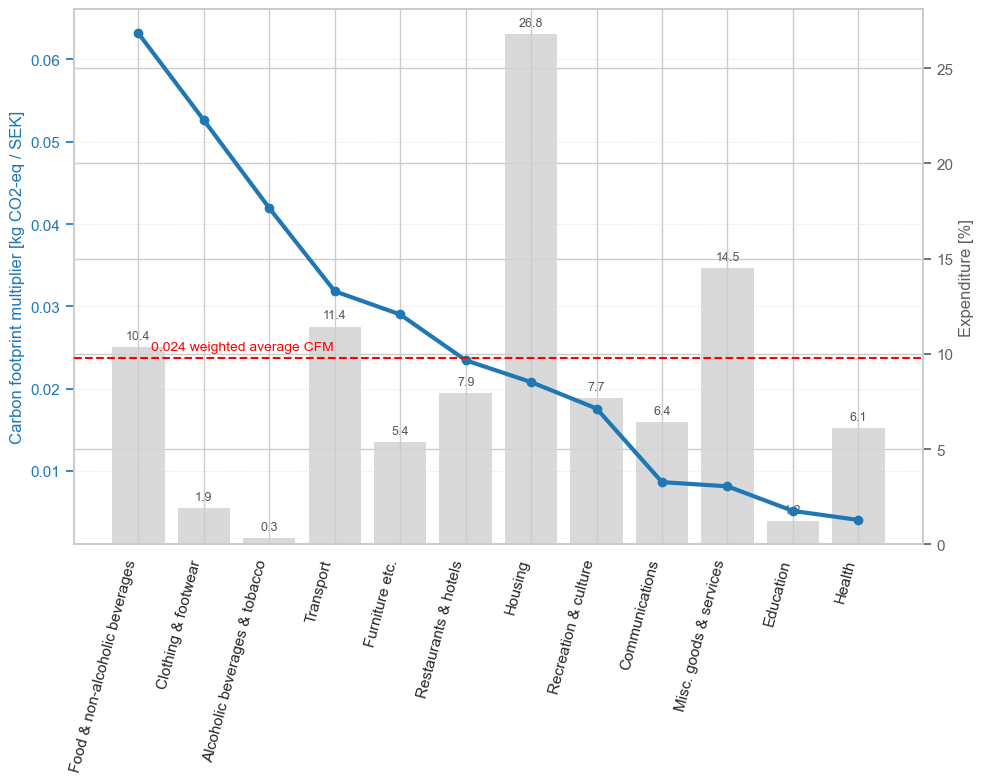

In [32]:
import matplotlib.pyplot as plt

# Expecting: hh_cfm index = 'Sector'
# columns: 'Final consumption expenditure by households [ratio]'
#          'Carbon Footprint multiplier [kg CO2-eq. per SEK]'

# Prepare data
df = (
    hh_cfm
    .rename(columns={
        'Final consumption expenditure by households [ratio]': 'ratio',
        'Carbon Footprint multiplier [kg CO2-eq. per SEK]': 'CFM',
    })
    .assign(Expenditure_pct=lambda d: d['ratio'] * 100.0)
    .reset_index()  # bring 'Sector' out of the index
    .sort_values('CFM', ascending=False)
    .reset_index(drop=True)
)

# Weighted average CFM (weights = ratio, not %)
wavg_cfm = np.average(df['CFM'], weights=df['ratio'])


plt.figure(figsize=(10, 8))
ax1 = plt.gca()           # left axis (CFM)
ax2 = ax1.twinx()         # right axis (Expenditure)

# --- crucial: control axes stacking across twins ---
ax1.set_zorder(2)         # bring left axis (line, red hline, text) to front
ax2.set_zorder(1)         # send bars' axis behind
ax1.patch.set_alpha(0)    # make front axis face transparent so bars stay visible

# Bars (right axis)
x = np.arange(len(df))
ax2.bar(x, df["Expenditure_pct"], color="lightgray", alpha=0.85, edgecolor="none", zorder=1)
for xi, y in zip(x, df["Expenditure_pct"]):
    ax2.text(xi, y + df["Expenditure_pct"].max()*0.01, f"{y:.1f}",
             ha="center", va="bottom", fontsize=9, color="#555", zorder=3)

# Blue line (left axis, now on top)
ax1.plot(x, df["CFM"], marker="o", linewidth=3, color="tab:blue", zorder=4)

# Red weighted-average line + label (also on top)
ax1.axhline(wavg_cfm, linestyle="--", color="red", linewidth=1.5, zorder=4)
ax1.text(0.2, wavg_cfm + (ax1.get_ylim()[1]-ax1.get_ylim()[0])*0.015,
         f"{wavg_cfm:.3f} weighted average CFM",
         color="red", fontsize=10, zorder=5)

# Labels/formatting
ax1.set_ylabel("Carbon footprint multiplier [kg CO2-eq / SEK]", color="tab:blue")
ax2.set_ylabel("Expenditure [%]", color="#606060")
ax1.tick_params(axis="y", colors="tab:blue")
ax2.tick_params(axis="y", colors="#606060")
ax1.set_xticks(x)
ax1.set_xticklabels(df["Sector"], rotation=75, ha="right")
ax1.grid(True, axis="y", linestyle=":", linewidth=0.7, alpha=0.6, zorder=0)
ax1.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 05 Potential Environmental Benefits (IO-LCA) — loaders

In [33]:
from pathlib import Path
import pandas as pd

def load_exio_factors(factors_dir: Path):
    """
    Build per-Category MRIO multipliers (kg CO2e / SEK) using the
    Blocket↔EXIO mapping file used in the earlier workflow.

    Returns
    -------
    exio_cf : pd.DataFrame
        Household CF table from §04 if present (kept for reference),
        else an empty DataFrame.
    mappings : pd.DataFrame
        Empty (kept for API compatibility; not used in this path).
    cat_mrio : pd.DataFrame
        Columns: ['Category', 'MRIO multiplier [kg CO2eq. per SEK]']
    """
    # Try to load §04 table (optional reference)
    cf_path = PROC / 'Y_HH_COICOP_perc_CF_SE.parquet'
    try:
        exio_cf = pd.read_parquet(cf_path)
        exio_cf.index.name = 'Sector'
    except Exception:
        exio_cf = pd.DataFrame()

    # Locate the mapping file (known path)
    src = factors_dir / "df_32cat_CFexio_RL.xlsx"
    if not src.exists():
        raise FileNotFoundError(f"Mapping file not found at {src}")

    df_32cat_CFexio = pd.read_excel(src, engine='openpyxl')

    # Convert MEUR → EUR → SEK
    M_EUR = 10**6
    EUR_TO_SEK = 11.025436  # same rate used in the working notebook
    col_meur = 'Exio product [GHG emissions per M EUR]'
    if col_meur not in df_32cat_CFexio.columns:
        raise KeyError(f"'{col_meur}' not found in {src.name}")

    df_32cat_CFexio['Exio product [kg CO2eq. per SEK]'] = (
        df_32cat_CFexio[col_meur] / (EUR_TO_SEK * M_EUR)
    )

    # Average to Category level and rename to MRIO multiplier
    df_cat = (
        df_32cat_CFexio.groupby('Category', as_index=False)['Exio product [kg CO2eq. per SEK]']
        .mean()
        .rename(columns={'Exio product [kg CO2eq. per SEK]': 'MRIO multiplier [kg CO2eq. per SEK]'})
    )

    # No 'mappings' in this pathway; keep API slot
    mappings = pd.DataFrame(columns=['Category','Sector'])

    return exio_cf, mappings, df_cat

## 05 Potential Environmental Benefits (IO-LCA) — compute

In [34]:
import pandas as pd
import numpy as np

def compute_potential_env_benefits(
    earnings_savings: pd.DataFrame,
    cat_mrio: pd.DataFrame = None
) -> pd.DataFrame:
    """
    Compute potential environmental benefits (spend-based) per transaction,
    matching the earlier working pipeline that uses per-Category MRIO multipliers.

    Required columns in `earnings_savings`:
      - 'Item' (optional but used in display)
      - 'Category', 'Region' (optional but kept if present)
      - 'Resale price [SEK]'
      - 'Retail price [SEK] (projected)'
      - 'Value retained (%)'

    `cat_mrio` must provide:
      - 'Category', 'MRIO multiplier [kg CO2eq. per SEK]'
    """
    df = earnings_savings.copy()

    # Ensure required columns exist (soft check on 'Item'/'Region')
    req = {'Category','Resale price [SEK]','Retail price [SEK] (projected)','Value retained (%)'}
    missing = req.difference(df.columns)
    if missing:
        raise KeyError(f"prices is missing required columns: {sorted(missing)}")

    # Merge Category-level MRIO multiplier
    if cat_mrio is None or cat_mrio.empty:
        raise ValueError("cat_mrio with 'Category' and 'MRIO multiplier [kg CO2eq. per SEK]' is required.")
    cat_mrio = cat_mrio.copy()
    cat_mrio['Category'] = cat_mrio['Category'].astype(str).str.strip()
    df['Category'] = df['Category'].astype(str).str.strip()

    df = df.merge(cat_mrio, on='Category', how='left')

    # Compute footprints
    mult = 'MRIO multiplier [kg CO2eq. per SEK]'
    df['Used product CF [kg CO2eq.] EAA']  = df['Resale price [SEK]'] * df[mult]
    df['New product CF [kg CO2eq.] EBZBA'] = df['Retail price [SEK] (projected)'] * df[mult]
    df['EBEAA [kg CO2eq.]'] = df['New product CF [kg CO2eq.] EBZBA'] - df['Used product CF [kg CO2eq.] EAA']

    # Reorder columns to match the working output
    keep_front = [c for c in ['Item','Category','Region','Resale price [SEK]',
                              'Retail price [SEK] (projected)','Value retained (%)', mult,
                              'Used product CF [kg CO2eq.] EAA','New product CF [kg CO2eq.] EBZBA',
                              'EBEAA [kg CO2eq.]'] if c in df.columns]
    others = [c for c in df.columns if c not in keep_front]
    df = df[keep_front + others]

    # --- Category-level summaries of EB ---
    df_cat = df.groupby('Category', as_index=False).agg(EBZBA_category_sum=('New product CF [kg CO2eq.] EBZBA','sum'),
    EBEAA_category_sum=('EBEAA [kg CO2eq.]','sum'),
    EBZBA_category_mean=('New product CF [kg CO2eq.] EBZBA','mean'),
    EBEAA_category_mean=('EBEAA [kg CO2eq.]','mean'))
    # converte kg to tonnes EB
    df_cat['EBZBA_category_sum']=df_cat['EBZBA_category_sum']/1000
    df_cat['EBEAA_category_sum']=df_cat['EBEAA_category_sum']/1000
    # calculate fold difference sum EB approaches
    df_cat['Fold difference EB approaches'] = df_cat['EBZBA_category_sum'] / df_cat['EBEAA_category_sum']
    # renaming columns
    df_cat = df_cat.rename(columns = {'EBZBA_category_sum':'Total EBZBA [tonnes CO2eq.]',
        'EBEAA_category_sum': 'Total EBEAA [tonnes CO2eq.]',
        'EBZBA_category_mean':'Average EBZBA [kg CO2eq.]',
        'EBEAA_category_mean': 'Average EBEAA [kg CO2eq.]'})
    # sort by Total EBZBA
    df_cat = df_cat.sort_values(by =['Total EBZBA [tonnes CO2eq.]'], ascending=False)


    return df, df_cat

In [35]:
# Run
exio_cf, mappings, cat_mrio = load_exio_factors(FAC)
df_EB, df_EB_cat = compute_potential_env_benefits(earnings_savings, cat_mrio)

write_df(df_EB, DER/'pot_env_ben.csv')
write_df(df_EB_cat, DER/'pot_env_ben_cat.csv')


## 06 Economic and environmental benefits

In [36]:
def build_economic_environmental_overview(df_EB: pd.DataFrame, rename_to_pae: bool = True) -> pd.DataFrame:
    # Create the category-level overview table combining counts, money, and emissions
    req_cols = {'Category', 'Resale price [SEK]', 'New product CF [kg CO2eq.] EBZBA', 'EBEAA [kg CO2eq.]'}
    missing = req_cols.difference(df_EB.columns)
    if missing:
        raise KeyError(f"df_EB missing columns: {sorted(missing)}")

    df = df_EB.copy()
    if 'Savings of buyers [SEK]' not in df.columns and 'Retail price [SEK] (projected)' in df.columns:
        df['Savings of buyers [SEK]'] = df['Retail price [SEK] (projected)'] - df['Resale price [SEK]']

    grp = df.groupby('Category', as_index=False).agg(
        **{
            '# of products' : ('Category', 'size'),
            'Earnings of sellers [M SEK]' : ('Resale price [SEK]', lambda s: s.sum() / 1e6),
            'Savings of buyers [M SEK]'   : ('Savings of buyers [SEK]', lambda s: s.sum() / 1e6) if 'Savings of buyers [SEK]' in df.columns else ('Resale price [SEK]', lambda s: np.nan),
            'EBZBA [tonnes CO2eq.]'       : ('New product CF [kg CO2eq.] EBZBA', lambda s: s.sum() / 1000.0),
            'EBEAA [tonnes CO2eq.]'       : ('EBEAA [kg CO2eq.]', lambda s: s.sum() / 1000.0),
        }
    )

    total_products = float(grp['# of products'].sum())
    total_earnings = float(grp['Earnings of sellers [M SEK]'].sum())
    total_savings  = float(grp['Savings of buyers [M SEK]'].sum()) if 'Savings of buyers [M SEK]' in grp.columns else np.nan

    grp['% of the total # of products']     = (grp['# of products'] / total_products * 100.0)
    grp['% of total earnings of sellers']   = (grp['Earnings of sellers [M SEK]'] / total_earnings * 100.0)
    if np.isfinite(total_savings) and total_savings > 0:
        grp['% of total savings of buyers'] = (grp['Savings of buyers [M SEK]'] / total_savings * 100.0)
    else:
        grp['% of total savings of buyers'] = np.nan

    grp['Rank by # of products']        = grp['# of products'].rank(method='dense', ascending=False).astype(int)
    grp['Rank by earnings of sellers']  = grp['Earnings of sellers [M SEK]'].rank(method='dense', ascending=False).astype(int)
    grp['Rank by savings of buyers']    = grp['Savings of buyers [M SEK]'].rank(method='dense', ascending=False).astype(int)
    grp['Rank by EBZBA']                = grp['EBZBA [tonnes CO2eq.]'].rank(method='dense', ascending=False).astype(int)
    grp['Rank by EBEAA']                = grp['EBEAA [tonnes CO2eq.]'].rank(method='dense', ascending=False).astype(int)

    if rename_to_pae:
        grp = grp.rename(columns={
            'EBZBA [tonnes CO2eq.]': 'PAEZBA [tonnes CO2eq.]',
            'EBEAA [tonnes CO2eq.]': 'PAEEAA [tonnes CO2eq.]',
            'Rank by EBZBA': 'Rank by PAEZBA',
            'Rank by EBEAA': 'Rank by PAEEAA',
        })

    ordered = [
        'Category',
        '# of products', 'Rank by # of products', '% of the total # of products',
        'Earnings of sellers [M SEK]', 'Rank by earnings of sellers', '% of total earnings of sellers',
        'Savings of buyers [M SEK]', 'Rank by savings of buyers',
        'EBZBA [tonnes CO2eq.]', 'Rank by EBZBA',
        'EBEAA [tonnes CO2eq.]', 'Rank by EBEAA',
    ]
    ordered = [c for c in ordered if c in grp.columns]
    grp = grp[ordered].sort_values('# of products', ascending=False).reset_index(drop=True)
    return grp

In [37]:
# Build and save Table 2
table2 = build_economic_environmental_overview(df_EB, rename_to_pae=False)
# Round all numeric columns to 2 decimals
table2 = table2.round(2)
write_df(table2, PROC/'table2_econ_env_benefits.parquet')
table2.to_excel(RES/'table2_econ_env_benefits.xlsx', index=False)

## 07 Re-spending Effects

In [38]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Iterable, Optional, Tuple
import pandas as pd
import numpy as np

@dataclass
class ReSpendingResult:
    disagg: pd.DataFrame
    by_category: Optional[pd.DataFrame] = None

def _find_col(df: pd.DataFrame, substrings: Iterable[str], *, required: bool=True) -> Optional[str]:
    """
    Return the first column name that contains ALL substrings (case-sensitive).
    Raise ValueError with a friendly message if required and not found.
    """
    candidates = list(df.columns)
    for s in substrings:
        candidates = [c for c in candidates if s in c]
    if not candidates:
        if required:
            raise ValueError(f"Could not find a column containing: {', '.join(substrings)} "
                             f"in columns: {list(df.columns)}")
        return None
    return candidates[0]

def _to_numeric(series: pd.Series) -> pd.Series:
    """Coerce to numeric and replace non-finite with 0 (explicit choice)."""
    out = pd.to_numeric(series, errors="coerce")
    return out.fillna(0.0).replace([np.inf, -np.inf], 0.0)

def _normalize_shares(sh: pd.Series) -> pd.Series:
    """
    Normalize shares to sum to 1. Accepts either 0–1 or 0–100 input.
    If sum > 1.5, we assume percentages and divide by 100.
    """
    sh = _to_numeric(sh)
    total = sh.sum()
    if total == 0:
        # Avoid division-by-zero; fall back to equal weights
        return pd.Series(np.ones(len(sh)) / max(len(sh), 1), index=sh.index)
    # If provided as percentages, sum is expected around 100 (± some noise)
    if total > 1.5:  # heuristic threshold
        sh = sh / 100.0
    # re-sum after potential /100, then normalize
    total2 = sh.sum()
    return sh / total2 if total2 else pd.Series(np.ones(len(sh)) / max(len(sh), 1), index=sh.index)

def compute_re_spending(
    earnings_savings: pd.DataFrame,
    hh_cfm: pd.DataFrame,
    *,
    return_category_summary: bool = True,
    category_col: str = "Item"
) -> ReSpendingResult:
    """
    Compute re-spending emissions for sellers' earnings and buyers' savings using
    HH carbon footprint multipliers.

    Parameters
    ----------
    earnings_savings : DataFrame
        Must include:
          - 'Earnings of sellers' (SEK or [M SEK] in the name)
          - 'Savings of buyers' (SEK or [M SEK] in the name)
        Will pass through Category and any EB columns if present.

    hh_cfm : DataFrame
        Must include a CF multiplier column (substring: 'Carbon Footprint multiplier')
        and a share column (substring: 'Final consumption expenditure').
        Shares may be 0–1 or 0–100; they will be normalized to sum to 1.

    return_category_summary : bool
        If True and `category_col` exists, also return a category-level sum.

    Returns
    -------
    ReSpendingResult
        .disagg: per-row emissions under Min / Weighted Avg / Max multipliers
        .by_category: aggregated sums by category (optional)
    """
    # --- hh_cfm hygiene ------------------------------------------------------
    # If Sector is index, lift it into a column (not strictly needed here but useful)
    if "Item" not in hh_cfm.columns:
        hh_cfm = hh_cfm.reset_index().rename(columns={"index": "Item"})

    cf_col = _find_col(hh_cfm, ["Carbon Footprint multiplier"])
    share_col = _find_col(hh_cfm, ["Final consumption expenditure"])

    cf_vals = _to_numeric(hh_cfm[cf_col])
    shares_norm = _normalize_shares(hh_cfm[share_col])

    cf_min = float(cf_vals.min())
    cf_max = float(cf_vals.max())
    cf_wavg = float((cf_vals * shares_norm).sum())  # normalized shares

    # --- earnings_savings hygiene ------------------------------------------------------
    earn_col = _find_col(earnings_savings, ["Earnings of sellers"])
    save_col = _find_col(earnings_savings, ["Savings of buyers"])

    def _detect_scale(colname: str) -> int:
        # Scale to SEK if column label mentions M SEK
        return 1_000_000 if "[M SEK]" in colname else 1

    earn_scale = _detect_scale(earn_col)
    save_scale = _detect_scale(save_col)

    earn_sek = _to_numeric(earnings_savings[earn_col]) * earn_scale
    save_sek = _to_numeric(earnings_savings[save_col]) * save_scale

    # passthrough columns: keep informative identifiers if present
    base_passthrough = [
        "Item",
        category_col,
        "EBZBA [tonnes CO2eq.]",
        "EBEAA [tonnes CO2eq.]"
    ]
    passthrough_cols = [c for c in base_passthrough if c in earnings_savings.columns]


    re_disagg = earnings_savings[passthrough_cols].copy() if passthrough_cols else pd.DataFrame(index=earnings_savings.index)
    re_disagg["Savings [SEK]"] = save_sek
    re_disagg["Earnings [SEK]"] = earn_sek

    scenarios: Tuple[Tuple[str, float], ...] = (("Min", cf_min), ("Wavg", cf_wavg), ("Max", cf_max))
    for label, cf in scenarios:
        s_col = f"{label} impact Savings [kg CO2e]"
        e_col = f"{label} impact Earnings [kg CO2e]"
        t_col = f"{label} impact Total [kg CO2e]"
        re_disagg[s_col] = save_sek * cf
        re_disagg[e_col] = earn_sek * cf
        re_disagg[t_col] = re_disagg[s_col] + re_disagg[e_col]

    # Optional, tidy category summary
    by_category = None
    if return_category_summary and category_col in re_disagg.columns:
        num_cols = re_disagg.select_dtypes(include=[np.number]).columns.tolist()
        by_category = (
            re_disagg.groupby(category_col, as_index=False)[num_cols]
            .sum(numeric_only=True)
            .sort_values(category_col, kind="stable")
        )

    return ReSpendingResult(disagg=re_disagg, by_category=by_category)


In [39]:
# run
earnings_savings = pd.read_parquet(PROC/'earnings_savings.parquet')
hh_cfm = pd.read_parquet(FAC/'Y_HH_COICOP_perc_CF_SE.parquet')

res = compute_re_spending(earnings_savings, hh_cfm, return_category_summary=True, category_col="Category")
write_df(res.disagg, PROC/'df_re_spending_effect_disagg.parquet')

if res.by_category is not None:
    write_df(res.by_category, PROC/'df_re_spending_effect_by_category.parquet')

### Plot Re-spending effects from economic benefits

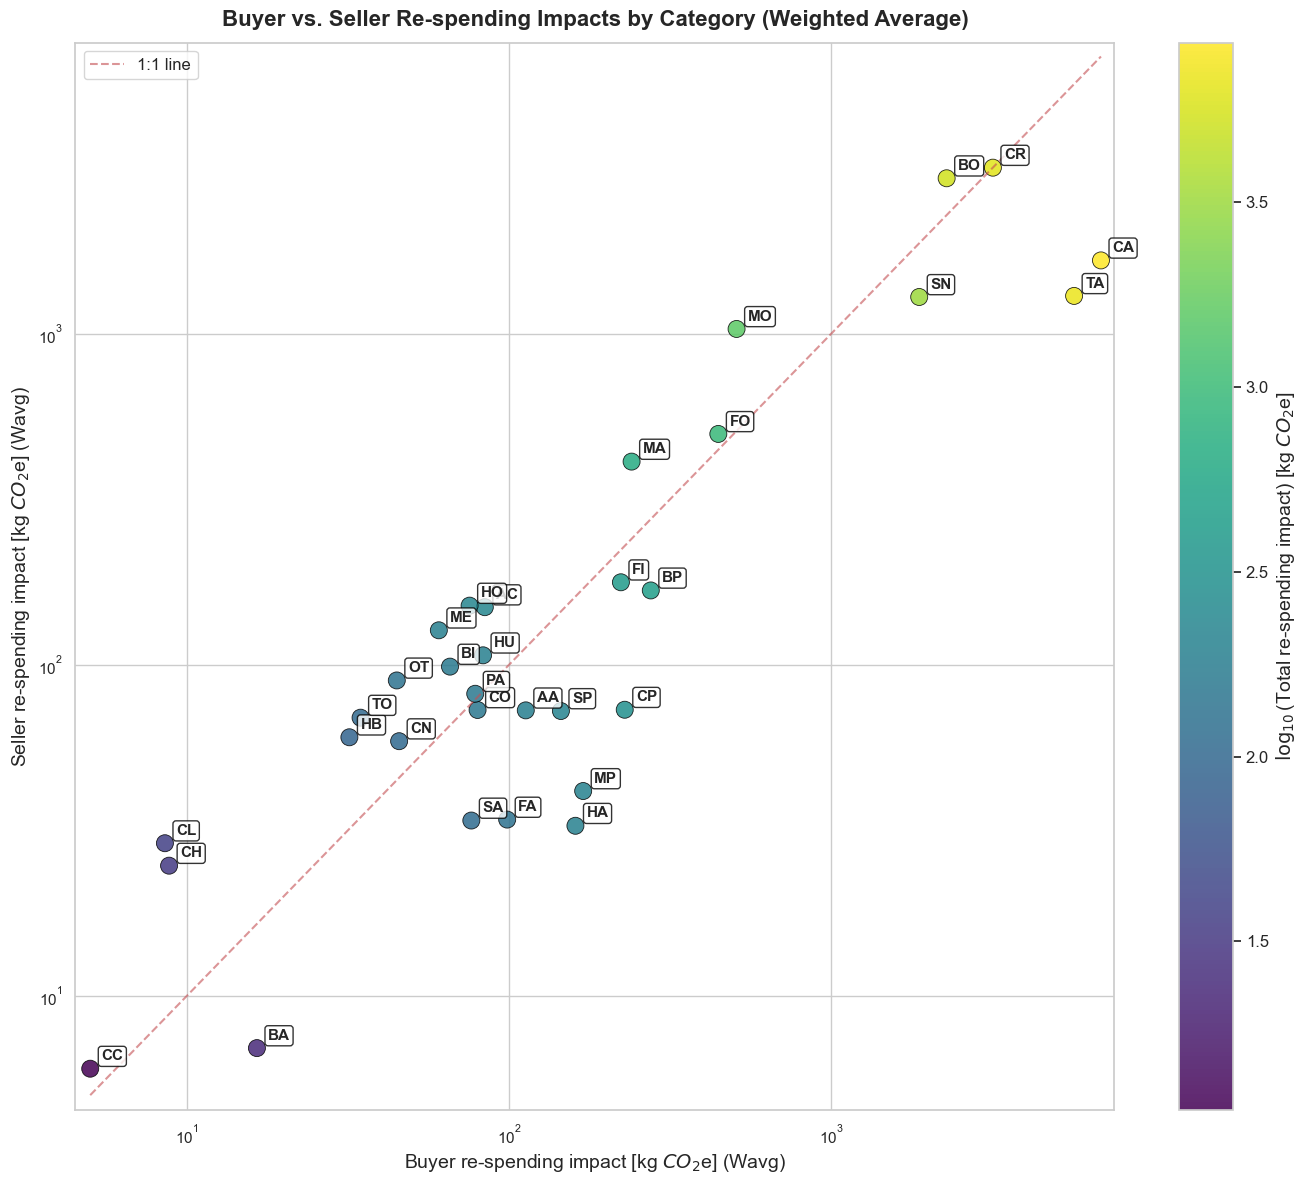


Category abbreviations used:
MO: Motorcycles
CP: Car parts & car accessories
FA: Furniture & home decor
SA: Sports & leisure equipment
CC: Children's clothing & shoes
MP: Motorcycle parts & accessories
AA: Audio & video
CA: Cars
CO: Computers & video games
CN: Construction & garden
OT: Other
HA: Housewares & appliances
CL: Clothes & shoes
CH: Children's articles & toys
CR: Caravans & campers
FO: Forestry & agricultural machinery
ME: Music equipment
FI: Fixtures & machines
PA: Phones & accessories
BA: Books & student literature
TO: Tools
HO: Horses & equestrian
BP: Boat parts & accessories
MA: Mopeds & doodlebug tractors
BI: Bicycles
TA: Trucks & construction
BO: Boats
SN: Snowmobiles
AC: Accessories & watches
HB: Hobby & collectibles
HU: Hunting & fishing
SP: Snowmobile parts & accessories


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load re-spending effect
df_re_spending_effect = pd.read_parquet(PROC/'df_re_spending_effect_disagg.parquet')

# ---------- helpers ----------
def _find_col(df: pd.DataFrame, required_substrings, fallback=None):
    """
    Return the first column whose name contains ALL required_substrings (case-insensitive).
    If not found, return fallback (if provided) or raise KeyError.
    """
    req = [s.lower() for s in required_substrings]
    for c in df.columns:
        lc = c.lower()
        if all(s in lc for s in req):
            return c
    if fallback is not None and fallback in df.columns:
        return fallback
    raise KeyError(f"Could not find column with substrings {required_substrings} in {list(df.columns)}")

# ---------- column detection (new vs. old names) ----------
x_col = _find_col(
    df_re_spending_effect,
    required_substrings=["wavg", "savings", "kg", "co2"],
    fallback="Wavg_impact_Savings_buyers_Kg_CO2"
)
y_col = _find_col(
    df_re_spending_effect,
    required_substrings=["wavg", "earnings", "kg", "co2"],
    fallback="Wavg_impact_Earnings_of_sellers_Kg_CO2"
)
cat_col = "Category" if "Category" in df_re_spending_effect.columns else _find_col(df_re_spending_effect, ["category"])

# ---------- aggregate ----------
impact_comparison = (
    df_re_spending_effect
    .groupby(cat_col, as_index=False)
    .agg({x_col: "mean", y_col: "mean"})
    .rename(columns={x_col: "buyers_kg", y_col: "sellers_kg", cat_col: "Category"})
)

# Handle zeros/negatives for log scale
epsilon = 1e-9
impact_comparison["buyers_kg"]  = np.clip(impact_comparison["buyers_kg"].abs(),  a_min=epsilon, a_max=None)
impact_comparison["sellers_kg"] = np.clip(impact_comparison["sellers_kg"].abs(), a_min=epsilon, a_max=None)

# Abbreviations
abbrev_dict = {
    'Motorcycles': 'MO','Car parts & car accessories': 'CP','Furniture & home decor': 'FA',
    'Sports & leisure equipment': 'SA',"Children's clothing & shoes": 'CC','Motorcycle parts & accessories': 'MP',
    'Audio & video': 'AA','Cars': 'CA','Computers & video games': 'CO','Construction & garden': 'CN','Other': 'OT',
    'Housewares & appliances': 'HA','Clothes & shoes': 'CL',"Children's articles & toys": 'CH','Caravans & campers': 'CR',
    'Forestry & agricultural machinery': 'FO','Music equipment': 'ME','Fixtures & machines': 'FI','Phones & accessories': 'PA',
    'Books & student literature': 'BA','Tools': 'TO','Horses & equestrian': 'HO','Boat parts & accessories': 'BP',
    'Mopeds & doodlebug tractors': 'MA','Bicycles': 'BI','Trucks & construction': 'TA','Boats': 'BO','Snowmobiles': 'SN',
    'Accessories & watches': 'AC','Hobby & collectibles': 'HB','Hunting & fishing': 'HU','Snowmobile parts & accessories': 'SP'
}

# ---------- plot ----------
plt.figure(figsize=(14, 12))
sns.set_style("whitegrid")

x = impact_comparison["buyers_kg"].to_numpy()
y = impact_comparison["sellers_kg"].to_numpy()
total = x + y
# color value: log10(total) but safe
color_val = np.log10(np.clip(total, a_min=epsilon, a_max=None))

scatter = plt.scatter(
    x, y,
    c=color_val,
    cmap="viridis",
    alpha=0.85,
    s=150,
    edgecolors="black",
    linewidths=0.6
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(r"$\log_{10}$(Total re-spending impact) [kg $CO_{2}$e]", fontsize=14)
cbar.ax.tick_params(labelsize=12)

# Labels
for _, row in impact_comparison.iterrows():
    abbrev = abbrev_dict.get(row["Category"], "NA")
    plt.annotate(
        abbrev,
        (row["buyers_kg"], row["sellers_kg"]),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.8, boxstyle="round,pad=0.2")
    )

# 1:1 line
xy_min = float(min(x.min(), y.min()))
xy_max = float(max(x.max(), y.max()))
plt.plot([xy_min, xy_max], [xy_min, xy_max], "r--", alpha=0.6, linewidth=1.5, label="1:1 line")

# Log scales and limits with a small margin
plt.xscale("log"); plt.yscale("log")
plt.xlim(xy_min*0.9, xy_max*1.1)
plt.ylim(xy_min*0.9, xy_max*1.1)

plt.xlabel("Buyer re-spending impact [kg $CO_{2}$e] (Wavg)", fontsize=14)
plt.ylabel("Seller re-spending impact [kg $CO_{2}$e] (Wavg)", fontsize=14)
plt.title("Buyer vs. Seller Re-spending Impacts by Category (Weighted Average)", fontsize=16, fontweight="bold", pad=12)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

# Abbrev reference
print("\nCategory abbreviations used:")
for category, abbrev in abbrev_dict.items():
    print(f"{abbrev}: {category}")


### Comparing re-spending effects with allocation approaches

cfm_min  = 0.004021 (Health)
cfm_max  = 0.063181 (Food & non-alcoholic beverages)
cfm_wavg = 0.023676


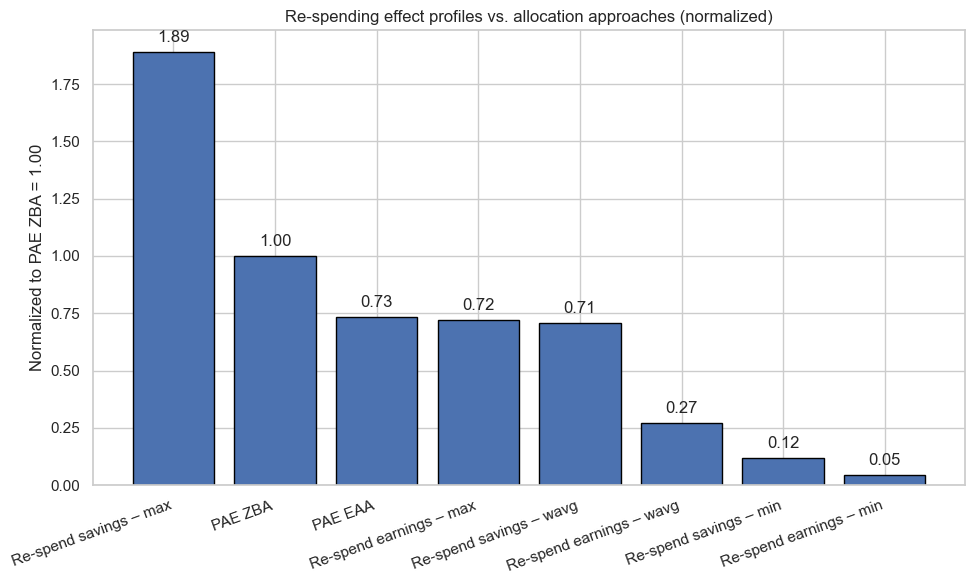

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

FIGPATH = RES / "normalized_impact_metrics_plot.png"  # output figure path

# ---------- load ----------
table2 = pd.read_parquet(PROC/'table2_econ_env_benefits.parquet')
hh_cfm  = pd.read_parquet(FAC/'Y_HH_COICOP_perc_CF_SE.parquet')

# ---------- sanity checks ----------
need_t2 = {
    'Category',
    'Earnings of sellers [M SEK]',
    'Savings of buyers [M SEK]',
    'EBZBA [tonnes CO2eq.]',
    'EBEAA [tonnes CO2eq.]'
}
missing = need_t2 - set(table2.columns)
if missing:
    raise KeyError(f"table2 missing columns: {missing}")

cfm_col = 'Carbon Footprint multiplier [kg CO2-eq. per SEK]'
w_col   = 'Final consumption expenditure by households [ratio]'
if cfm_col not in hh_cfm.columns or w_col not in hh_cfm.columns:
    raise KeyError(f"hh_cfm must contain '{cfm_col}' and '{w_col}'")

# ---------- compact working view ----------
df_re = table2[list(need_t2)].copy()

# Optional: rename EB columns to PAE for clarity
df_re = df_re.rename(columns={
    'EBZBA [tonnes CO2eq.]': 'PAE_ZBA [tonnes CO2e]',
    'EBEAA [tonnes CO2eq.]': 'PAE_EAA [tonnes CO2e]'
})

# ---------- totals row ----------
sums_df = df_re.drop(columns=['Category']).sum(axis=0).to_frame().T
# keep useful originals for normalization later
# (these are totals across all categories in tonnes CO2e)
# Columns now: ['Earnings of sellers [M SEK]', 'Savings of buyers [M SEK]',
#               'PAE_ZBA [tonnes CO2e]', 'PAE_EAA [tonnes CO2e]']

# ---------- ensure Sector column exists ----------
if 'Sector' not in hh_cfm.columns and getattr(hh_cfm.index, 'name', None) == 'Sector':
    hh_cfm = hh_cfm.reset_index()

# ---------- CF multiplier min/max/weighted ----------
# robust to NaNs in weights/values
vals = hh_cfm[cfm_col].astype(float).to_numpy()
wts  = hh_cfm[w_col].astype(float).to_numpy()

# indices for min/max among non-NaN values
valid_idx = np.isfinite(vals)
if not valid_idx.any():
    raise ValueError("No finite values in CF multiplier column.")

idx_min = np.argmin(vals[valid_idx])
idx_max = np.argmax(vals[valid_idx])
# map back to original row indices
valid_rows = np.where(valid_idx)[0]
rmin = valid_rows[idx_min]
rmax = valid_rows[idx_max]

cfm_min = float(vals[rmin])
cfm_max = float(vals[rmax])
cfm_min_sector = str(hh_cfm.loc[rmin, 'Sector'])
cfm_max_sector = str(hh_cfm.loc[rmax, 'Sector'])

# weighted average; ignore NaN weights/values
mask = np.isfinite(vals) & np.isfinite(wts) & (wts > 0)
cfm_wavg = np.average(vals[mask], weights=wts[mask]) if mask.any() else np.nanmean(vals)

print(
    f"cfm_min  = {cfm_min:.6f} ({cfm_min_sector})\n"
    f"cfm_max  = {cfm_max:.6f} ({cfm_max_sector})\n"
    f"cfm_wavg = {cfm_wavg:.6f}"
)

# ---------- re-spending effects (in tonnes CO2e) ----------
# Rationale: MSEK * 1e6 (SEK) * (kg/SEK) / 1000 = MSEK * 1000 * (tonnes/SEK)
msek_to_tonnes_factor = 1000.0

sums_df['ReSpend_Buyers_min  [tonnes CO2e]'] = sums_df['Savings of buyers [M SEK]']    * msek_to_tonnes_factor * cfm_min
sums_df['ReSpend_Buyers_max  [tonnes CO2e]'] = sums_df['Savings of buyers [M SEK]']    * msek_to_tonnes_factor * cfm_max
sums_df['ReSpend_Buyers_wavg [tonnes CO2e]'] = sums_df['Savings of buyers [M SEK]']    * msek_to_tonnes_factor * cfm_wavg

sums_df['ReSpend_Sellers_min  [tonnes CO2e]'] = sums_df['Earnings of sellers [M SEK]'] * msek_to_tonnes_factor * cfm_min
sums_df['ReSpend_Sellers_max  [tonnes CO2e]'] = sums_df['Earnings of sellers [M SEK]'] * msek_to_tonnes_factor * cfm_max
sums_df['ReSpend_Sellers_wavg [tonnes CO2e]'] = sums_df['Earnings of sellers [M SEK]'] * msek_to_tonnes_factor * cfm_wavg

# ---------- build normalized, tidy table ----------
keep_cols = [
    'PAE_ZBA [tonnes CO2e]',
    'PAE_EAA [tonnes CO2e]',
    'ReSpend_Buyers_min  [tonnes CO2e]',
    'ReSpend_Buyers_wavg [tonnes CO2e]',
    'ReSpend_Buyers_max  [tonnes CO2e]',
    'ReSpend_Sellers_min  [tonnes CO2e]',
    'ReSpend_Sellers_wavg [tonnes CO2e]',
    'ReSpend_Sellers_max  [tonnes CO2e]'
]
df_res = sums_df[keep_cols].copy()

# normalize by PAE_ZBA (choose your baseline; change if you prefer PAE_EAA)
baseline = 'PAE_ZBA [tonnes CO2e]'
norm = df_res.iloc[0] / df_res.iloc[0][baseline]

# tidy for plotting
tidy = (
    norm.rename('Normalized value')
        .reset_index()
        .rename(columns={'index': 'Metric'})
        .sort_values('Normalized value', ascending=False)
)

# nicer display names
name_map = {
    'PAE_ZBA [tonnes CO2e]': 'PAE ZBA',
    'PAE_EAA [tonnes CO2e]': 'PAE EAA',
    'ReSpend_Buyers_min  [tonnes CO2e]':  'Re-spend savings – min',
    'ReSpend_Buyers_wavg [tonnes CO2e]': 'Re-spend savings – wavg',
    'ReSpend_Buyers_max  [tonnes CO2e]':  'Re-spend savings – max',
    'ReSpend_Sellers_min  [tonnes CO2e]': 'Re-spend earnings – min',
    'ReSpend_Sellers_wavg [tonnes CO2e]':'Re-spend earnings – wavg',
    'ReSpend_Sellers_max  [tonnes CO2e]': 'Re-spend earnings – max',
}
tidy['Metric'] = tidy['Metric'].map(name_map).fillna(tidy['Metric'])

# ---------- plot ----------
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(tidy['Metric'], tidy['Normalized value'], edgecolor='black')

# value labels
for x, y in zip(tidy['Metric'], tidy['Normalized value']):
    ax.annotate(f"{y:.2f}", xy=(x, y), xytext=(0, 5), textcoords="offset points", ha='center', va='bottom')

ax.set_ylabel('Normalized to PAE ZBA = 1.00')
ax.set_xlabel('')
ax.set_title('Re-spending effect profiles vs. allocation approaches (normalized)')
plt.xticks(rotation=20, ha='right')
fig.tight_layout()
plt.savefig(FIGPATH, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# If you also want the underlying (non-normalized) totals and the normalized tidy table:
totals_out = df_res.T.rename(columns={0: 'Total [tonnes CO2e]'})
norm_out   = tidy.copy()


## 08 CRE computation and plot

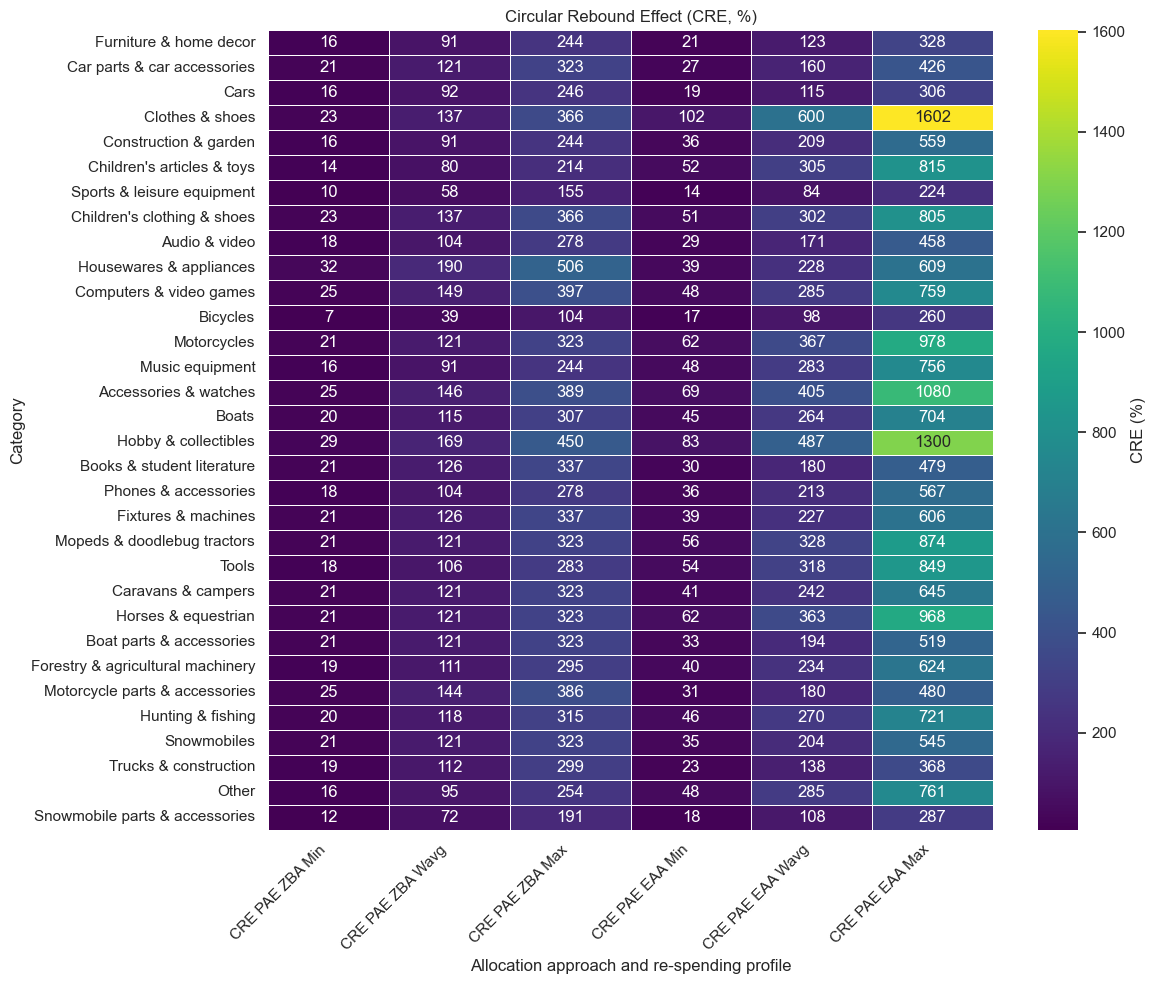

In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- config ----------
FIGPATH = RES / "fig_cre_heatmap.png"  # output figure path

# ---------- load ----------
table2 = pd.read_parquet(PROC / "table2_econ_env_benefits.parquet")
df_re_agg = pd.read_parquet(PROC / "df_re_spending_effect_by_category.parquet")

# ---------- select / rename upfront ----------
peb_cols = ["Category", "EBZBA [tonnes CO2eq.]", "EBEAA [tonnes CO2eq.]"]
df_peb = table2.loc[:, peb_cols].copy()

re_cols = ["Category", "Min impact Total [kg CO2e]", "Wavg impact Total [kg CO2e]", "Max impact Total [kg CO2e]"]
df_re_agg = df_re_agg.loc[:, re_cols].copy()

# ---------- units: kg -> tonnes ----------
kg_cols = [c for c in df_re_agg.columns if c.endswith("[kg CO2e]")]
df_re_agg[kg_cols] = df_re_agg[kg_cols] / 1000.0
df_re_agg = df_re_agg.rename(columns={
    "Min impact Total [kg CO2e]": "Min impact Total [tonnes CO2e]",
    "Wavg impact Total [kg CO2e]": "Wavg impact Total [tonnes CO2e]",
    "Max impact Total [kg CO2e]": "Max impact Total [tonnes CO2e]",
})

# ---------- merge ----------
df = df_peb.merge(df_re_agg, on="Category", how="left", validate="one_to_one")

# ---------- helpers ----------
def safe_divide(num: pd.Series, den: pd.Series) -> pd.Series:
    # Avoid divide-by-zero; keep NaN where denominator is 0/NaN
    den_safe = den.replace(0, np.nan)
    return num / den_safe

# ---------- CRE = (PRE / PEB) * 100 ----------
pairs = [
    ("EBZBA [tonnes CO2eq.]", "ZBA"),
    ("EBEAA [tonnes CO2eq.]", "EAA"),
]
imp_cols = [
    ("Min impact Total [tonnes CO2e]", "Min"),
    ("Wavg impact Total [tonnes CO2e]", "Wavg"),
    ("Max impact Total [tonnes CO2e]", "Max"),
]

for peb_col, peb_tag in pairs:
    for imp_col, imp_tag in imp_cols:
        out_col = f"CRE PAE {peb_tag} {imp_tag}"
        df[out_col] = safe_divide(df[imp_col], df[peb_col]) * 100

# ---------- final table for plotting ----------
plot_cols = [
    "CRE PAE ZBA Min", "CRE PAE ZBA Wavg", "CRE PAE ZBA Max",
    "CRE PAE EAA Min", "CRE PAE EAA Wavg", "CRE PAE EAA Max",
]
df_cre = df[["Category"] + plot_cols].set_index("Category")

# Optional: sort categories (e.g., by Wavg ZBA)
#df_cre = df_cre.sort_values("CRE PAE ZBA Wavg", ascending=True)

# ---------- plotting ----------
plt.figure(figsize=(12, 10))

# highlight 100% as a threshold, use a diverging palette centered at 100:
#sns.heatmap(df_cre, cmap="RdYlGn_r", annot=True, fmt=".0f", linewidths=.5, center=100,
#            cbar_kws={"label": "CRE (%)"})

# Otherwise, a sequential palette works fine:
sns.heatmap(df_cre, cmap="viridis", annot=True, fmt=".0f", linewidths=.5,
            cbar_kws={"label": "CRE (%)"})

plt.title("Circular Rebound Effect (CRE, %)")
plt.xlabel("Allocation approach and re-spending profile")
plt.ylabel("Category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# Optional save
plt.savefig(FIGPATH, dpi=300)
plt.show()

# rounded:
df_cre_display = df_cre.round(0).astype("Int64")  # keeps NaN as <NA>
# print(df_cre_display)  # or write to file if needed


# 09 Methodological limitations

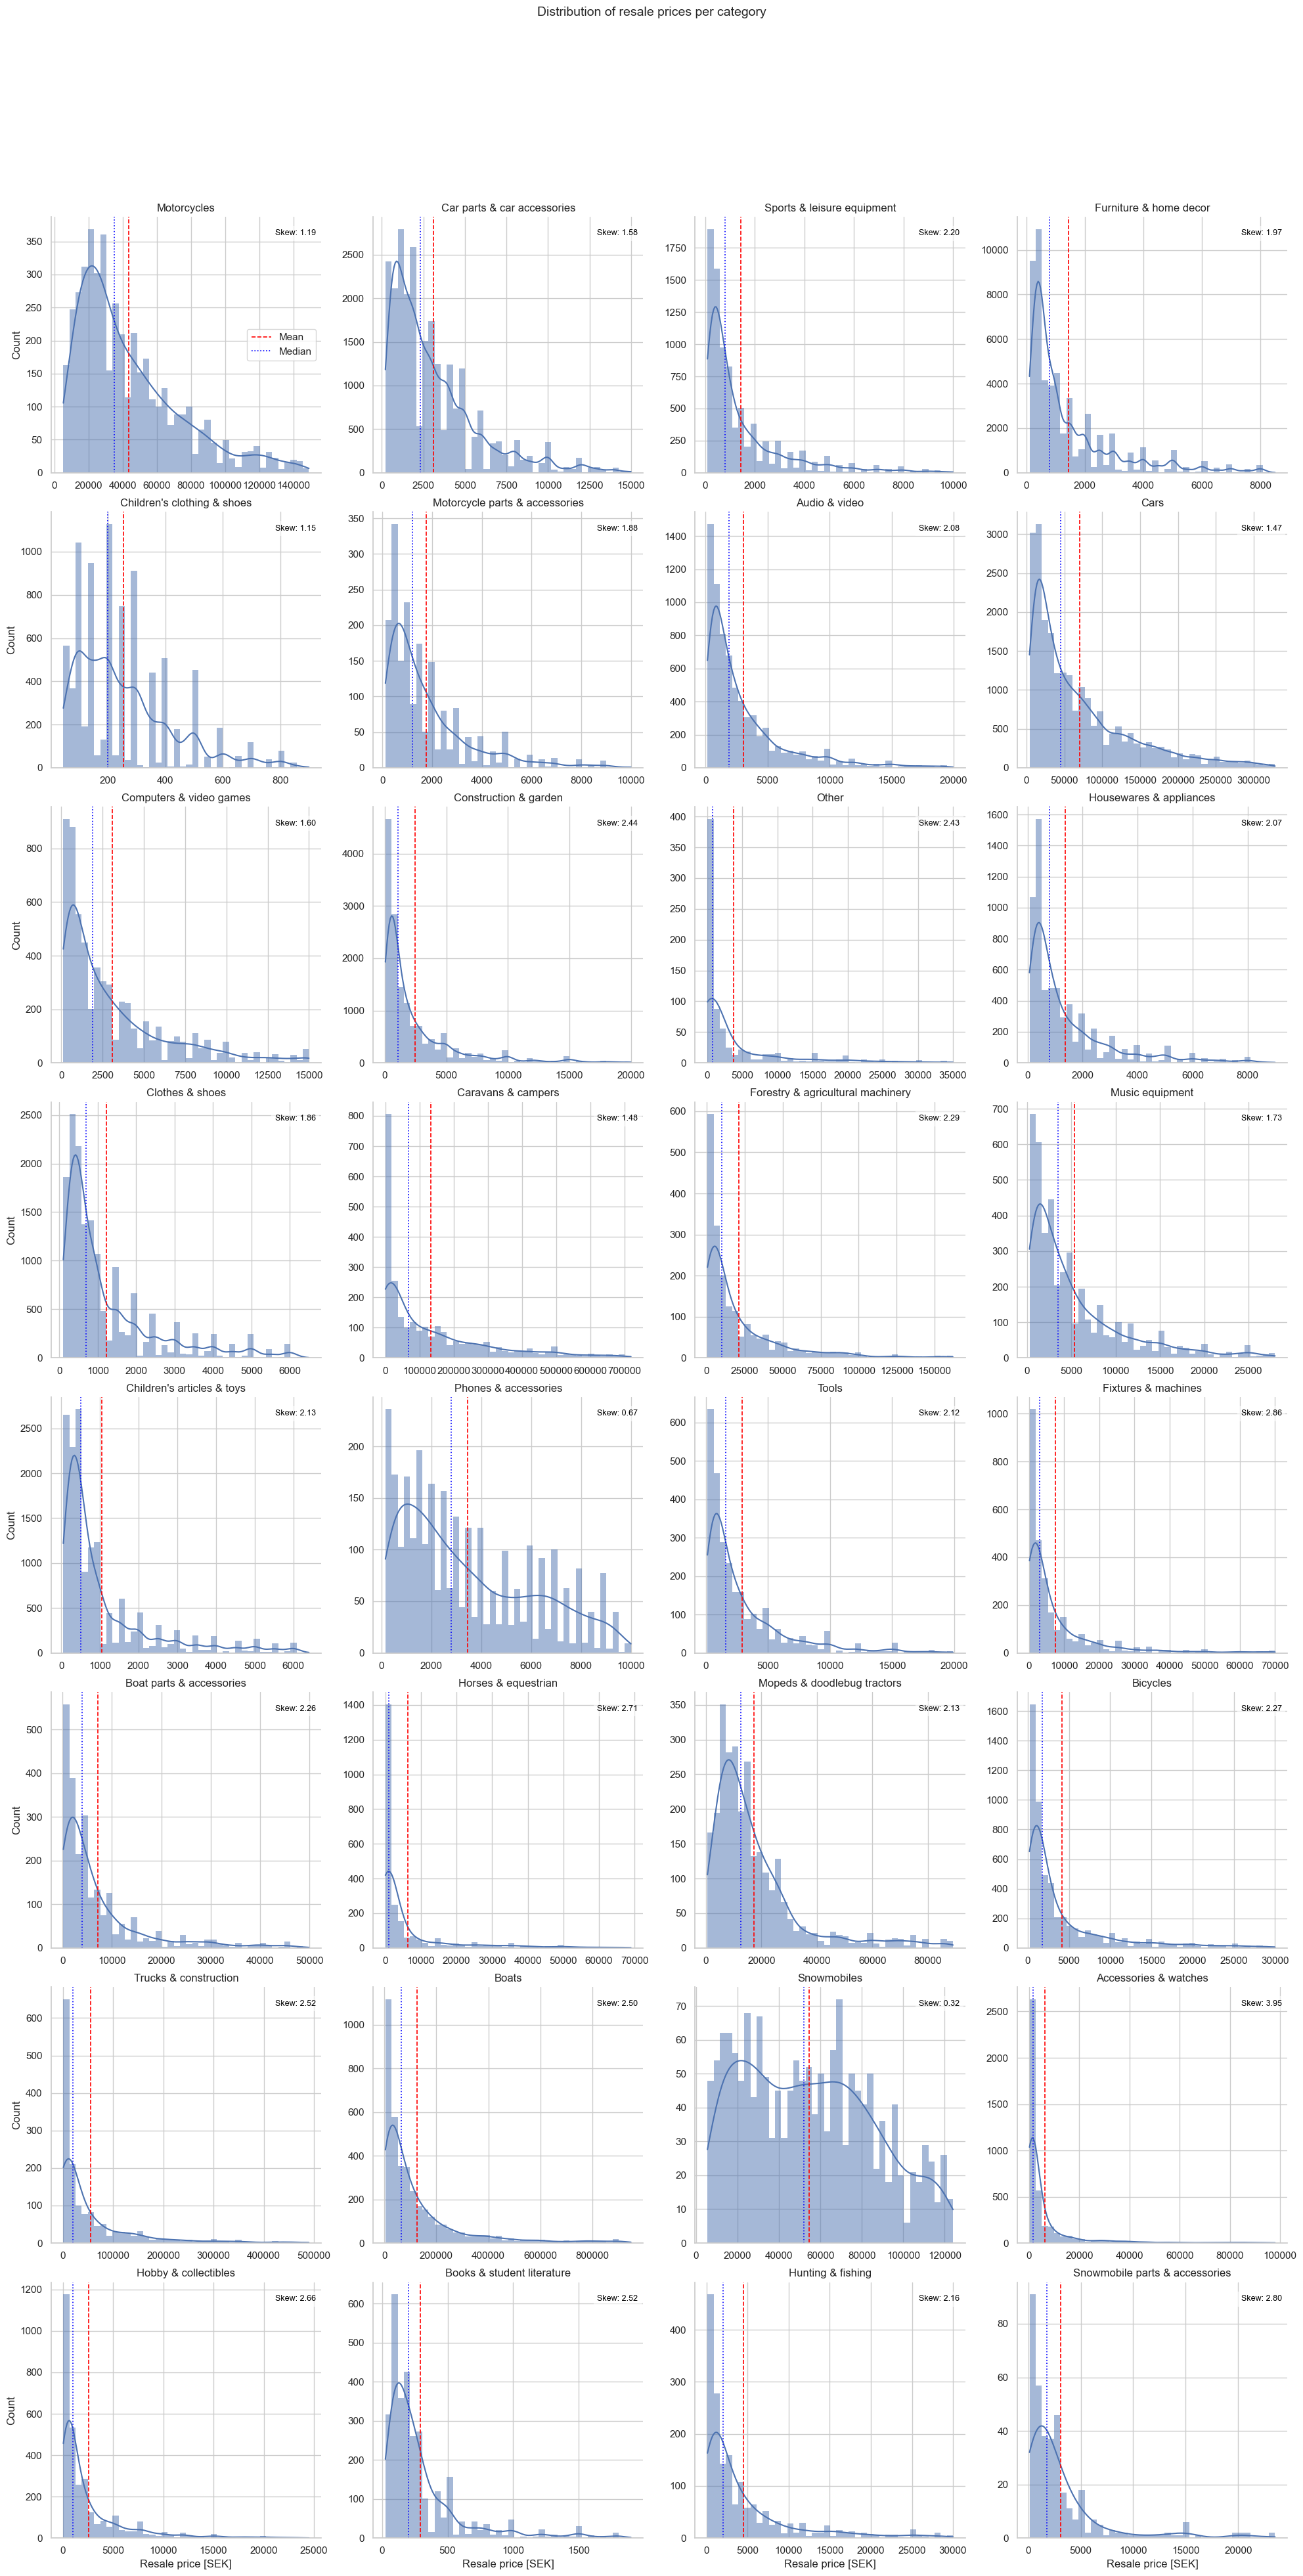

In [45]:
import numpy as np
from scipy.stats import skew

df = pd.read_parquet(PROC / 'df_cleaned_en.parquet')

# --- Create the displot ---
g = sns.displot(
    data=df_EB,
    x="Resale price [SEK]",
    col="Category",
    col_wrap=4,
    bins=40,
    kde=True,
    facet_kws={'sharex': False, 'sharey': False},
    common_bins=False,
    common_norm=False
)

# --- Annotate each subplot ---
for ax, category in zip(g.axes.flatten(), df['Category'].unique()):
    # Subset data for this category
    data_cat = df[df['Category'] == category]['Price'].dropna()
    
    # Compute stats
    mean_val = data_cat.mean()
    median_val = data_cat.median()
    skew_val = skew(data_cat, nan_policy='omit')
    
    # Add vertical lines
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label='Mean')
    ax.axvline(median_val, color='blue', linestyle=':', linewidth=1.2, label='Median')
    
    # Add skewness annotation
    ax.text(0.98, 0.95,
            f"Skew: {skew_val:.2f}",
            transform=ax.transAxes,
            ha='right', va='top',
            fontsize=9, color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    
    # Optional: Add legend in one of the subplots only
    if ax == g.axes.flatten()[0]:
        ax.legend()

# --- Titles and layout ---
g.set_titles("{col_name}")
g.set_axis_labels("Resale price [SEK]", "Count")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribution of resale prices per category", fontsize=14)
plt.show()
